# Problem set 5: Adiabatic state preparation

## Introduction

In adiabatic quantum computing, the system is initialized in the easy-to-prepare ground state of a Hamiltonian $H_0$, and then the Hamiltonian is gradually transformed into $H_1$, which is constructed in such a way that the groundstate of $H_1$ encodes the solution to a difficult problem. The transformation of $H_0$ to $H_1$ can for example be written in the form

$\displaystyle H(t) = (1-\lambda(t)) H_0 + \lambda(t) H_1$

where $\lambda(t)$ is a function that goes from goes from $0$ to $1$ when $t$ goes from $0$ to $t_{\rm final}$.

If this gradual tranformation is slow enough (satisfying the adiabicity critera), the evolution of the system will remain in its ground state.

If the Hamiltonian is transformed from $H_0$ to $H_1$ too quickly, the system will get excited from the ground state and the adiabatic computing algorithm fails.

In this notebook we explore the dynamics of a spin Hamiltonian that is transformed from a simple Hamiltonian with an easy to prepare ground state, into a Hamiltonian with a strongly-correlated antiferromagnetic ground state.

In [1]:
import sys
sys.path.append("..")  
import Adva_Quant_Inform as aqi # customer package(full path to AQI_SS26)

import matplotlib.pyplot as plt
import numpy as np  
# from numpy import * 
from qutip import *
from qutip import tensor, qeye, sigmax, sigmay, sigmaz, basis

%matplotlib inline

## Exercise 1: Setting up the system

Consider the Hamiltonians
$$
H_0 = -\sum_{i=1}^N \sigma^x_i
$$
and
$$
H_1 = \frac{1}{2}\sum_{i=1}^{N-1} J_z \sigma^z_i\sigma^z_{i+1} - \frac{1}{2}\sum_{i=1}^{N} h \sigma^z_i
$$
with $J_z=2\pi$ and $h=0.5\cdot 2\pi$.

Build the matrix representation of $H_0$ and $H_1$ and the initial state vector $|\psi(0)\rangle=\left[(|0\rangle+|1\rangle)/\sqrt{2}\right]^{\otimes N}$. Use a small $N$ to check the correctness of your code manually. As a first step, you may want to use the function buildSparseGateSingle(n, i, gate) from exercise sheet 3 to build the matrix representations of single qubit Pauli operators acting on an $N$-qubit system.


### Construct the initial state

In [2]:
# Construct the initial state with all spins aligned along x
# which coincides with the ground state for H0
ket0 = 1/np.sqrt(2)*basis(2,0) + 1/np.sqrt(2)*basis(2,1) 
print(ket0)

Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.70710678]
 [0.70710678]]


## Exercise 2: Instantaneous eigenstates

Using $N=5$ and $\lambda(t)=t/t_{\rm final}$ with $t_{\rm final}=50$, calculate the eigenvalues and eigenstates of $H(t)$ for a grid of 100 points between $t=0$ and $t_{\rm final}$ and plot the lowest 20 eigenenergies as a function of time.

Also calculate the overlap of instantaneous ground state with the initial state and with the ground state of $H_1$ as a function of time. You should see how the character of the state changes gradually from one to the other. At the point where the excitation gap is smallest this change should be the fastest.

In [3]:
# define function for H(t)
def H_t(t, H0, H1, N):
    H_at_t = (1-t/taumax)*H0(N) + (t/taumax)*H1(N)
    return H_at_t

### Eigenspectrum of $H(t)$ for $N=5$

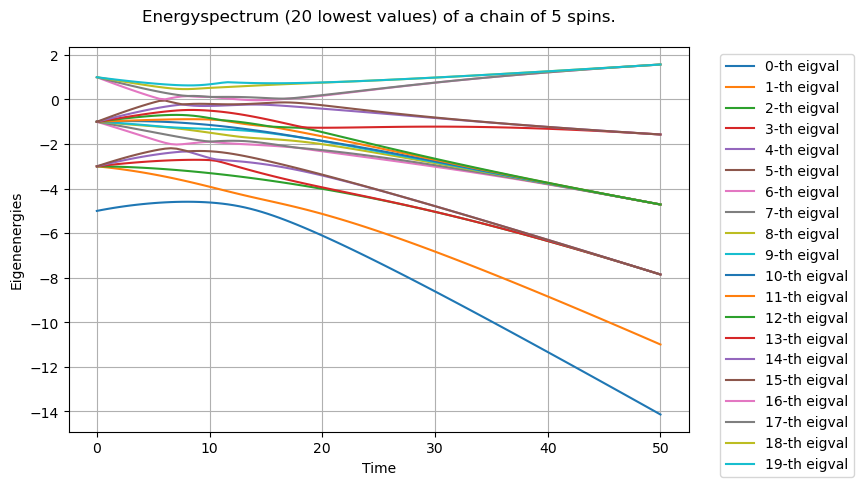

In [4]:
N = 5 # number of spins
M = 20  # number of eigenenergies to plot

# storage for eigenvalues
eig_energy_list = []

# total time of the sweep increase taumax to make the sweep more adiabatic
taumax = 50.0
taulist = np.linspace(0, taumax, 100) #plot for 100 steps

for t in taulist:
    H =H_t(t,aqi.hamiltonians.H0,aqi.hamiltonians.H1,N)
    eigenvalues, _ = H.eigenstates() # compute all eigenvalues
    eig_entry = list(eigenvalues[:M])  # take first M=20 eigenvalues
    eig_energy_list.append(eig_entry)

# convert to NumPy array for easier analysis/plotting
eig_energy_array = np.array(eig_energy_list)

plt.figure(figsize=(8, 5)) # set size

for i in range(M):
    plt.plot(taulist, eig_energy_array[:,i], label=f'{i}'"-th eigval")

plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left") # legend outside
plt.xlabel("Time")
plt.ylabel("Eigenenergies")
plt.title("Energyspectrum (%d lowest values) of a chain of %d spins.\n " % (M,5))
plt.grid(True)
plt.show()

### Instantaneous ground state of $H(t)$

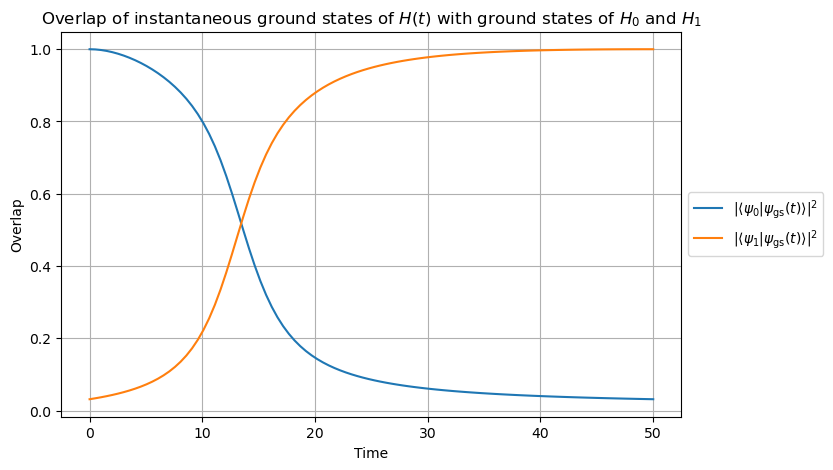

In [5]:
# compute the instantaneous ground state of H(t)
Nspin = 5 # number of spins
# total time of the sweep - increase taumax to make the sweep more adiabatic
taumax = 50.0
taulist = np.linspace(0, taumax, 100) 

# ground states of H0 and H1
psi0_N = aqi.operators.psi0(Nspin)
psiH1_N = aqi.hamiltonians.psiH1(Nspin)

overlaps_psi0 = [] # storage for overlaps with H0 (initial ground state)
overlaps_psiH1 = [] # storage for overlaps with H1

# loop over time to compute ground state and overlap with psi0 and psiH1
for t in taulist:
    H =H_t(t,aqi.hamiltonians.H0,aqi.hamiltonians.H1,Nspin)
    _, eigenstates = H.eigenstates()
    psi_gs = eigenstates[0]  # ground state at time t
    
    overlap_with_psi0 = abs(psi0_N.overlap(psi_gs))**2  # probability (overlap() is in QuTiP)
    overlap_with_psiH1 = abs(psiH1_N.overlap(psi_gs))**2
    
    overlaps_psi0.append(overlap_with_psi0)
    overlaps_psiH1.append(overlap_with_psiH1)
    

# plotting the overlap vs. time
plt.figure(figsize=(8, 5))
plt.plot(taulist, overlaps_psi0, label=r"$|\langle \psi_0 | \psi_{\mathrm{gs}}(t) \rangle|^2$")
plt.plot(taulist, overlaps_psiH1, label=r"$|\langle \psi_1 | \psi_{\mathrm{gs}}(t) \rangle|^2$")
plt.xlabel("Time")
plt.ylabel("Overlap")
plt.title("Overlap of instantaneous ground states of $H(t)$ with ground states of $H_{0}$ and $H_{1}$")
plt.grid(True)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

### Instantaneous excited states of $H(t)$

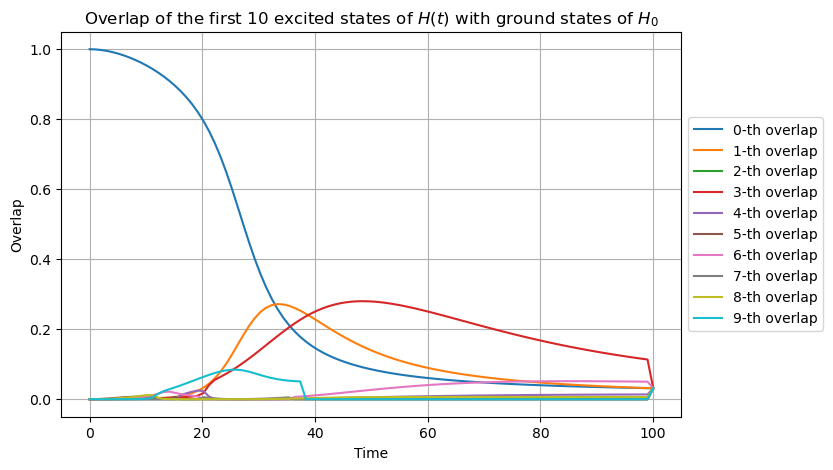

In [6]:
# compute instantaneous excited states of H(t)
Nspin = 5 # number of spins
M = 10  # number of eigenenergies to plot
taumax = 100.0 # total time of the sweep
taulist = np.linspace(0, taumax, 100) 

psi0_N = aqi.operators.psi0(Nspin) # ground states of H0
overlaps_psi0_list = [] # storage for overlaps with H0 (initial ground state)

for t in taulist:
    H = H_t(t, aqi.hamiltonians.H0, aqi.hamiltonians.H1, N)
    _, eigenvectors = H.eigenstates()
    
    overlaps_at_t = []  # reset per time step
    for i in range(M):
        overlap_with_psi0 = abs(psi0_N.overlap(eigenvectors[i]))**2 
        overlaps_at_t.append(overlap_with_psi0)
    
    overlaps_psi0_list.append(overlaps_at_t)  # one row per time step

# convert to NumPy array for easier analysis/plotting
prob_psi0_array = np.array(overlaps_psi0_list)

# plotting the overlap vs. time
plt.figure(figsize=(8, 5))
for i in range(M):
    plt.plot(taulist, prob_psi0_array[:,i], label=f'{i}'"-th overlap")
plt.xlabel("Time")
plt.ylabel("Overlap")
plt.title("Overlap of the first %d excited states of $H(t)$ with ground states of $H_{0}$" % (M))
plt.grid(True)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

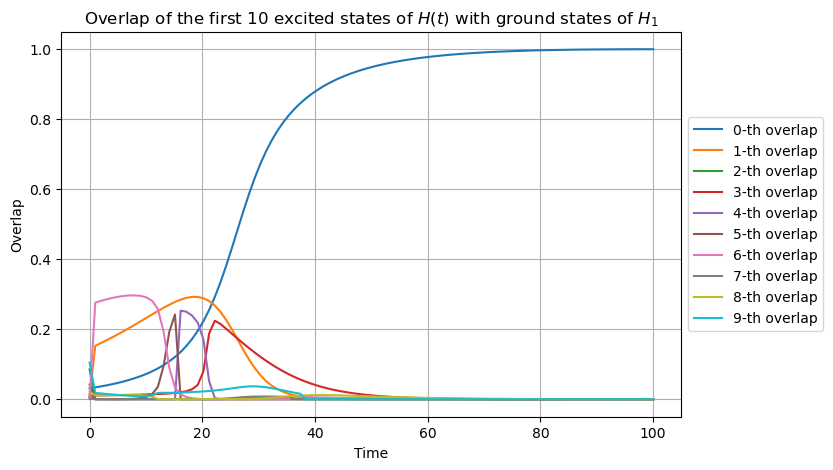

In [7]:
# compute instantaneous excited states of H(t)
Nspin = 5 # number of spins
M = 10  # number of eigenenergies to plot
taumax = 100.0 # total time of the sweep
taulist = np.linspace(0, taumax, 100) 

psiH1_N = aqi.hamiltonians.psiH1(Nspin) # ground states of H1
overlaps_psiH1_list = [] # storage for overlaps with H1

for t in taulist:
    H = H_t(t, aqi.hamiltonians.H0, aqi.hamiltonians.H1, Nspin)
    _, eigenvectors = H.eigenstates()
    
    overlaps_at_t = []  # reset per time step
    for i in range(M):
        overlap_with_psiH1 = abs(psiH1_N.overlap(eigenvectors[i]))**2 
        overlaps_at_t.append(overlap_with_psiH1)
    
    overlaps_psiH1_list.append(overlaps_at_t)  # one row per time step

# convert to NumPy array for easier analysis/plotting
prob_psiH1_array = np.array(overlaps_psiH1_list)

# plotting the overlap vs. time
plt.figure(figsize=(8, 5))
for i in range(M):
    plt.plot(taulist, prob_psiH1_array[:,i], label=f'{i}'"-th overlap")
plt.xlabel("Time")
plt.ylabel("Overlap")
plt.title("Overlap of the first %d excited states of $H(t)$ with ground states of $H_{1}$" % (M))
plt.grid(True)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

## Exercise 3: Time evolution

Simulate the time evolution under $H(t)$ using the parameters given above. You can use the qutip function mesolve(), which allows you to solve the time-dependent Schrödinger equation. (see https://qutip.org/docs/latest/apidoc/functions.html#module-qutip.mesolve)

Calculate the overlap of the obtained $|\psi(t)\rangle$ with the instantaneous eigenstates and plot them as a function of time. Try this for different values of $t_{\rm final}$ and interpret your results.

Compare results for an odd number of qubits to an even number of qubits (i.e N=5 vs N=6). What causes the difference?

### Evolvution for $N=5$ and $t_{\text{max}}=50$

In [8]:
Nspin = 5
taumax = 50.0 # total time of the sweep
taulist = np.linspace(0, taumax, 100) 

# ground states of H0 and H1 for Nspin
psi0_N = aqi.operators.psi0(Nspin)
psiH1_N = aqi.hamiltonians.psiH1(Nspin)

# compute the time-evolved state for Nspin
psi_te_N = aqi.unitaries.psi_te(Nspin, taulist)

overlaps_psi0_te = [] # storage for overlaps with H0 (initial ground state)
overlaps_psiH1_te = [] # storage for overlaps with H1

# loop over time to compute overlap with psi0 and psiH1
for t in range(len(taulist)):
    overlap_with_psi0_te = abs(psi0_N.overlap(psi_te_N[t]))**2 
    overlap_with_psiH1_te = abs(psiH1_N.overlap(psi_te_N[t]))**2
    
    overlaps_psi0_te.append(overlap_with_psi0_te)
    overlaps_psiH1_te.append(overlap_with_psiH1_te)

# plotting the overlap vs. time
plt.figure(figsize=(8, 5))
plt.plot(taulist, overlaps_psi0_te, label=r"$|\langle \psi_0 | \psi(t) \rangle|^2$")
plt.plot(taulist, overlaps_psiH1_te, label=r"$|\langle \psi_1 | \psi(t) \rangle|^2$")
plt.xlabel("Time")
plt.ylabel("Overlap")
plt.title("Overlap of the time-evolved state with ground states of $H_{0}$ and $H_{1}$")
plt.grid(True)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

NameError: name 'psi0' is not defined

### Evolvution for $N=5$ and $t_{\text{max}}=100$

In [ ]:
Nspin = 5
taumax = 100.0 # total time of the sweep
taulist = np.linspace(0, taumax, 100) 

# ground states of H0 and H1 for Nspin
psi0_N = aqi.operators.psi0(Nspin)
psiH1_N = aqi.hamiltonians.psiH1(Nspin)

# compute the time-evolved state for Nspin
psi_te_N = aqi.unitaries.psi_te(Nspin, taulist)

overlaps_psi0_te = [] # storage for overlaps with H0 (initial ground state)
overlaps_psiH1_te = [] # storage for overlaps with H1

# loop over time to compute overlap with psi0 and psiH1
for t in range(len(taulist)):
    # probability (overlap() is in QuTiP)
    overlap_with_psi0_te = abs(psi0_N.overlap(psi_te_N[t]))**2 
    overlap_with_psiH1_te = abs(psiH1_N.overlap(psi_te_N[t]))**2
    
    overlaps_psi0_te.append(overlap_with_psi0_te)
    overlaps_psiH1_te.append(overlap_with_psiH1_te)

# plotting the overlap vs. time
plt.figure(figsize=(8, 5))
plt.plot(taulist, overlaps_psi0_te, label=r"$|\langle \psi_0 | \psi(t) \rangle|^2$")
plt.plot(taulist, overlaps_psiH1_te, label=r"$|\langle \psi_1 | \psi(t) \rangle|^2$")
plt.xlabel("Time")
plt.ylabel("Overlap")
plt.title("Overlap of the time-evolved state with ground states of $H_{0}$ and $H_{1}$")
plt.grid(True)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

### Evolvution for $N=6$ and $t_{\text{max}}=100$

For N=6 the ground state of the problem Hamiltonian is degenerate. This causes a different behavior at the end, where the occupations get split up between the two possible ground states. For the success of the ground state preparation, this is not an issue since both ground states and any of their superpositions are valid solutions.

In [ ]:
Nspin = 6
taumax = 100.0 # total time of the sweep
taulist = np.linspace(0, taumax, 100) 

# ground states of H0 and H1 for Nspin
psi0_N = aqi.operators.psi0(Nspin)
psiH1_N = aqi.hamiltonians.psiH1(Nspin)

# compute the time-evolved state for Nspin
psi_te_N = aqi.unitaries.psi_te(Nspin, taulist)

overlaps_psi0_te = [] # storage for overlaps with H0 (initial ground state)
overlaps_psiH1_te = [] # storage for overlaps with H1

# loop over time to compute overlap with psi0 and PsiH1
for t in range(len(taulist)):
    # probability (overlap() is in QuTiP)
    overlap_with_psi0_te = abs(psi0_N.overlap(psi_te_N[t]))**2 
    overlap_with_psiH1_te = abs(psiH1_N.overlap(psi_te_N[t]))**2
    
    overlaps_psi0_te.append(overlap_with_psi0_te)
    overlaps_psiH1_te.append(overlap_with_psiH1_te)

# plotting the overlap vs. time
plt.figure(figsize=(8, 5))
plt.plot(taulist, overlaps_psi0_te, label=r"$|\langle \psi_0 | \psi(t) \rangle|^2$")
plt.plot(taulist, overlaps_psiH1_te, label=r"$|\langle \psi_1 | \psi(t) \rangle|^2$")
plt.xlabel("Time")
plt.ylabel("Overlap")
plt.title("Overlap of the time-evolved state with ground states of $H_{0}$ and $H_{1}$")
plt.grid(True)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

## Extra:

### Eigenspectrum of $H(t)$ for $N=4$

In [ ]:
Nspin = 4
taumax = 100.0 # total time of the sweep
taulist = np.linspace(0, taumax, 100) 

# ground states of H0 and H1 for Nspin
psi0_N = aqi.operators.psi0(Nspin)
psiH1_N = aqi.hamiltonians.psiH1(Nspin)

# compute the time-evolved state for Nspin
psi_te_N = aqi.unitaries.psi_te(Nspin, taulist)

overlaps_psi0_te = [] # storage for overlaps with H0 (initial ground state)
overlaps_psiH1_te = [] # storage for overlaps with H1

# loop over time to compute overlap with psi0 and PsiH1
for t in range(len(taulist)):
    # probability (overlap() is in QuTiP)
    overlap_with_psi0_te = abs(psi0_N.overlap(psi_te_N[t]))**2 
    overlap_with_psiH1_te = abs(psiH1_N.overlap(psi_te_N[t]))**2
    
    overlaps_psi0_te.append(overlap_with_psi0_te)
    overlaps_psiH1_te.append(overlap_with_psiH1_te)

# plotting the overlap vs. time
plt.figure(figsize=(8, 5))
plt.plot(taulist, overlaps_psi0_te, label=r"$|\langle \psi_0 | \psi(t) \rangle|^2$")
plt.plot(taulist, overlaps_psiH1_te, label=r"$|\langle \psi_1 | \psi(t) \rangle|^2$")
plt.xlabel("Time")
plt.ylabel("Overlap")
plt.title("Overlap of the time-evolved state with ground states of $H_{0}$ and $H_{1}$")
plt.grid(True)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

### Overlap between instantaneous ground states and time-evolved states for $N=5$

In [ ]:
# compute the instantaneous ground state of H(t)
Nspin = 5 # number of spins
# total time of the sweep - increase taumax to make the sweep more adiabatic
taumax = 50.0
taulist = np.linspace(0, taumax, 100) 

# compute the time-evolved state for Nspin
psi_te_N = aqi.unitaries.psi_te(Nspin, taulist)

all_psi_gs = []
for t in taulist:
    H = H_t(t, aqi.hamiltonians.H0, aqi.hamiltonians.H1, Nspin)
    _, eigenstates = H.eigenstates()
    psi_gs = eigenstates[0]  # ground state at time t
    all_psi_gs.append(psi_gs)
    
overlaps = []
for t in range(len(taulist)):
    overlap_with_psi_te = abs(psi_te_N[t].overlap(all_psi_gs[t]))**2
    overlaps.append(overlap_with_psi_te)
    

# plotting the overlap vs. time
plt.figure(figsize=(8, 5))
plt.plot(taulist, overlaps, label=r"$|\langle \psi(t) | \psi_{\mathrm{gs}}(t) \rangle|^2$")
plt.xlabel("Time")
plt.ylabel("Overlap")
plt.title("Overlap of instantaneous ground states of $H(t)$ and time-evolved state")
plt.grid(True)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

### Overlap between instantaneous ground states and time-evolved states for $N=6$

In [ ]:
# compute the instantaneous ground state of H(t)
Nspin = 6 # number of spins
# total time of the sweep - increase taumax to make the sweep more adiabatic
taumax = 50.0
taulist = np.linspace(0, taumax, 100) 

# compute the time-evolved state for Nspin
psi_te_N = aqi.unitaries.psi_te(Nspin, taulist)

all_psi_gs = []
for t in taulist:
    H = H_t(t, aqi.hamiltonians.H0, aqi.hamiltonians.H1, Nspin)
    _, eigenstates = H.eigenstates()
    psi_gs = eigenstates[0]  # ground state at time t
    all_psi_gs.append(psi_gs)
    
overlaps = []
for t in range(len(taulist)):
    overlap_with_psi_te = abs(psi_te_N[t].overlap(all_psi_gs[t]))**2
    overlaps.append(overlap_with_psi_te)
    

# plotting the overlap vs. time
plt.figure(figsize=(8, 5))
plt.plot(taulist, overlaps, label=r"$|\langle \psi(t) | \psi_{\mathrm{gs}}(t) \rangle|^2$")
plt.xlabel("Time")
plt.ylabel("Overlap")
plt.title("Overlap of instantaneous ground states of $H(t)$ and time-evolved state")
plt.grid(True)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()